#1: Imports

In [1]:
import os
import sys
import time
import json
import csv
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = '/content/drive/MyDrive/Transformer_Mine'
CHECKPOINT_DIR = os.path.join(PROJECT_ROOT, 'checkpoints/small_scale')
FIGURES_DIR = os.path.join(PROJECT_ROOT, 'figures')
EXPERIMENTS_CSV = os.path.join(PROJECT_ROOT, 'experiments/results.csv')

In [3]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/Transformer_Mine

Mounted at /content/drive
/content/drive/MyDrive/Transformer_Mine


In [4]:

from transformer_model import TiedTransformer
from training import (
    label_smoothing_loss,
    TransformerLRSchedule,
    train_step,
    eager_train_step,
    create_checkpoint_manager,
    restore_checkpoint,
    compute_validation_loss,
)
from data_pipeline import load_raw_pairs, build_tf_dataset
from tokenizer import BPETokenizer

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("TensorFlow:", tf.__version__)
print("Project root:", PROJECT_ROOT)

TensorFlow: 2.20.0
Project root: /content/drive/MyDrive/Transformer_Mine


# 2: Experiment Definition

This experiment uses a reduced model on real data.

It is explicitly labelled **COLAB-SCALE** and is **NOT** the paper reproduction.

## Purpose

1. Validate the pipeline on real EN-DE translation data
2. Confirm loss decreases on a real vocabulary (~8k tokens)
3. Measure training throughput (tokens/sec, steps/sec)
4. Confirm checkpointing and session recovery work
5. Get a baseline BLEU before scaling to Transformer Base

## CONFIGURATION

```text
num_layers : 3
d_model    : 256
num_heads  : 4
d_ff       : 1024
dropout    : 0.1
vocab_size : 8000  (Stage B BPE)
dataset    : Tatoeba EN-DE (~80k pairs after filtering)
batch_size : 64
steps      : 10000
warmup     : 2000
```

## ORIGINAL TRANSFORMER BASE (paper)

```text
num_layers : 6
d_model    : 512
num_heads  : 8
d_ff       : 2048
dropout    : 0.1
vocab_size : ~37000
dataset    : WMT14 EN-DE (~4.5M pairs)
```


In [5]:
EXPERIMENT_ID = 'small_scale_01'

In [6]:
MODEL_CONFIG = {
    'num_layers' : 3,
    'd_model' : 256,
    'num_heads' : 4,
    'd_ff' : 1024,
    'dropout' : 0.1,
    'max_len' : 100,
}

In [7]:
TRAIN_CONFIG = {
    'vocab_size' : 8000,
    'batch_size' : 64,
    'total_steps' : 10000,
    'warmup_steps' : 2000,
    'label_smoothing' : 0.1,
    'max_seq_len' : 100,
}

In [8]:
print("Experiment:", EXPERIMENT_ID)
print()
print("CONFIGURATION :")
for k, v in {**MODEL_CONFIG, **TRAIN_CONFIG}.items():
    print(f"{k:<20} : {v}")

Experiment: small_scale_01

CONFIGURATION :
num_layers           : 3
d_model              : 256
num_heads            : 4
d_ff                 : 1024
dropout              : 0.1
max_len              : 100
vocab_size           : 8000
batch_size           : 64
total_steps          : 10000
warmup_steps         : 2000
label_smoothing      : 0.1
max_seq_len          : 100


#3: Load Stage B Data and Tokenizer

In [9]:


VOCAB_DIR_B = os.path.join(PROJECT_ROOT, 'vocab/stage_b')
STAGE_B_DIR = os.path.join(PROJECT_ROOT, 'datasets/stage_b')

tokenizer = BPETokenizer.load(VOCAB_DIR_B)
print(f"Tokenizer loaded. Vocab size: {tokenizer.vocab_size}")

src_train, tgt_train = load_raw_pairs(
    os.path.join(STAGE_B_DIR, 'train.en'),
    os.path.join(STAGE_B_DIR, 'train.de'),
)
src_val, tgt_val = load_raw_pairs(
    os.path.join(STAGE_B_DIR, 'val.en'),
    os.path.join(STAGE_B_DIR, 'val.de'),
)

print(f"Train pairs : {len(src_train):,}")
print(f"Val pairs : {len(src_val):,}")

MAX_LEN    = TRAIN_CONFIG['max_seq_len']
BATCH_SIZE = TRAIN_CONFIG['batch_size']
VOCAB_SIZE = tokenizer.vocab_size

# ── Cache paths ───────────────────────────────────────────────
CACHE_DIR   = os.path.join(PROJECT_ROOT, 'datasets/stage_b/cache')
os.makedirs(CACHE_DIR, exist_ok=True)

TRAIN_CACHE = os.path.join(CACHE_DIR, f'train_maxlen{MAX_LEN}.npz')
VAL_CACHE   = os.path.join(CACHE_DIR, f'val_maxlen{MAX_LEN}.npz')


def encode_dataset(src_lines, tgt_lines, tokenizer, max_len, label=''):
    """
    Encode all sentence pairs into numpy arrays.
    Shows progress every 10% of lines.
    """
    import numpy as np

    n = len(src_lines)
    enc_inputs  = np.zeros((n, max_len), dtype=np.int32)
    dec_inputs  = np.zeros((n, max_len), dtype=np.int32)
    dec_targets = np.zeros((n, max_len), dtype=np.int32)

    log_every = max(1, n // 10)

    for i, (src, tgt) in enumerate(zip(src_lines, tgt_lines)):
        if i % log_every == 0:
            print(f"  {label} encoding {i:>6}/{n}  ({100*i/n:.0f}%)")

        # Source
        src_ids = [tokenizer.bos_id] + tokenizer.encode(src) + [tokenizer.eos_id]
        src_ids = src_ids[:max_len]
        enc_inputs[i, :len(src_ids)] = src_ids

        # Target
        tgt_ids = [tokenizer.bos_id] + tokenizer.encode(tgt) + [tokenizer.eos_id]
        tgt_in  = tgt_ids[:-1][:max_len]
        tgt_out = tgt_ids[1:][:max_len]
        dec_inputs[i,  :len(tgt_in)]  = tgt_in
        dec_targets[i, :len(tgt_out)] = tgt_out

    print(f"  {label} encoding done.")
    return enc_inputs, dec_inputs, dec_targets


def load_or_encode(src_lines, tgt_lines, tokenizer, max_len, cache_path, label=''):
    """Load encoded arrays from cache if available, else encode and save."""
    if os.path.exists(cache_path):
        print(f"Loading {label} from cache: {cache_path}")
        data = np.load(cache_path)
        return data['enc'], data['dec_in'], data['dec_tgt']
    else:
        print(f"Encoding {label} ({len(src_lines):,} pairs) — this takes a few minutes...")
        enc, dec_in, dec_tgt = encode_dataset(
            src_lines, tgt_lines, tokenizer, max_len, label=label
        )
        np.savez_compressed(cache_path, enc=enc, dec_in=dec_in, dec_tgt=dec_tgt)
        print(f"Saved to cache: {cache_path}")
        return enc, dec_in, dec_tgt


import numpy as np
import time

t0 = time.time()
enc_train, dec_in_train, dec_tgt_train = load_or_encode(
    src_train, tgt_train, tokenizer, MAX_LEN, TRAIN_CACHE, label='train'
)
print(f"  train ready in {time.time()-t0:.1f}s")

t0 = time.time()
enc_val, dec_in_val, dec_tgt_val = load_or_encode(
    src_val, tgt_val, tokenizer, MAX_LEN, VAL_CACHE, label='val'
)
print(f"  val ready in {time.time()-t0:.1f}s")

# Build tf.data directly from numpy arrays (no re-encoding)
def arrays_to_dataset(enc, dec_in, dec_tgt, batch_size, shuffle=False, seed=42):
    ds = tf.data.Dataset.from_tensor_slices((enc, dec_in, dec_tgt))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(enc), seed=seed,
                        reshuffle_each_iteration=True)
    ds = ds.batch(batch_size, drop_remainder=False)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_dataset = arrays_to_dataset(
    enc_train, dec_in_train, dec_tgt_train,
    BATCH_SIZE, shuffle=True,
)
val_dataset = arrays_to_dataset(
    enc_val, dec_in_val, dec_tgt_val,
    BATCH_SIZE, shuffle=False,
)

# Inspect one batch
for enc_in, dec_in, dec_tgt in train_dataset.take(1):
    print(f"\nTrain batch shapes:")
    print(f"  enc_input  : {enc_in.shape}")
    print(f"  dec_input  : {dec_in.shape}")
    print(f"  dec_target : {dec_tgt.shape}")
    print()
    print("First example:")
    print(f"  src : {tokenizer.decode(enc_in[0].numpy())}")
    print(f"  tgt : {tokenizer.decode(dec_tgt[0].numpy())}")

Tokenizer loaded. Vocab size: 8000
Train pairs : 44,581
Val pairs   : 2,000
Encoding train (44,581 pairs) — this takes a few minutes...
  train encoding      0/44581  (0%)
  train encoding   4458/44581  (10%)
  train encoding   8916/44581  (20%)
  train encoding  13374/44581  (30%)
  train encoding  17832/44581  (40%)
  train encoding  22290/44581  (50%)
  train encoding  26748/44581  (60%)
  train encoding  31206/44581  (70%)
  train encoding  35664/44581  (80%)
  train encoding  40122/44581  (90%)
  train encoding  44580/44581  (100%)
  train encoding done.
Saved to cache: /content/drive/MyDrive/Transformer_Mine/datasets/stage_b/cache/train_maxlen100.npz
  train ready in 1178.8s
Encoding val (2,000 pairs) — this takes a few minutes...
  val encoding      0/2000  (0%)
  val encoding    200/2000  (10%)
  val encoding    400/2000  (20%)
  val encoding    600/2000  (30%)
  val encoding    800/2000  (40%)
  val encoding   1000/2000  (50%)
  val encoding   1200/2000  (60%)
  val encoding  

# 4: GPU Memory and Throughput Estimate

Estimates memory usage and warns if configuration is likely to cause OOM on Colab before committing to training.


In [10]:
import subprocess

In [13]:
def get_gpu_info():
    try:
        result = subprocess.run(
            ['nvidia-smi',
             '--query-gpu=name,memory.total,memory.free,memory.used',
             '--format=csv,noheader,nounits'],
            capture_output=True, text=True
        )
        parts = result.stdout.strip().split(', ')
        return {
            'name' : parts[0],
            'total_mb' : int(parts[1]),
            'free_mb' : int(parts[2]),
            'used_mb' : int(parts[3]),
        }
    except Exception as e:
        return {'error': str(e)}

In [14]:


gpu_info = get_gpu_info()
print("GPU information:")
if 'error' in gpu_info:
    print(f"Could not query GPU: {gpu_info['error']}")
else:
    print(f" Name : {gpu_info['name']}")
    print(f" Total VRAM : {gpu_info['total_mb']:,} MB")
    print(f"Used VRAM : {gpu_info['used_mb']:,} MB")
    print(f"Free VRAM : {gpu_info['free_mb']:,} MB")


# Rough memory estimate for one batch
# Each tensor element = 4 bytes (float32)
d_model = MODEL_CONFIG['d_model']
batch = TRAIN_CONFIG['batch_size']
seq = TRAIN_CONFIG['max_seq_len']
num_heads = MODEL_CONFIG['num_heads']
num_layers = MODEL_CONFIG['num_layers']

# Attention weights per layer: batch x heads x seq x seq
attn_mem = batch * num_heads * seq * seq * 4 * num_layers * 2
# Activations (rough): batch x seq x d_model x num_layers x 2 (enc+dec)
act_mem  = batch * seq * d_model * num_layers * 2 * 4 * 10
total_est_mb = (attn_mem + act_mem) / 1_048_576

print(f"Rough memory estimate for one batch:")
print(f"  batch={batch}, seq={seq}, d_model={d_model}, layers={num_layers}")
print(f"  Estimated activation memory : ~{total_est_mb:.0f} MB")
print()

if 'free_mb' in gpu_info and total_est_mb > gpu_info['free_mb'] * 0.7:
    print("WARNING: estimated memory exceeds 70% of free VRAM.")
    print("Consider reducing batch_size or max_seq_len.")
else:
    print("Memory estimate is within safe range.")

GPU information:
 Name : Tesla T4
 Total VRAM : 15,360 MB
Used VRAM : 107 MB
Free VRAM : 14,806 MB
Rough memory estimate for one batch:
  batch=64, seq=100, d_model=256, layers=3
  Estimated activation memory : ~434 MB

Memory estimate is within safe range.


#  5: Build Model and Smoke Test

Runs 50 steps before committing to full training.

Verifies:

* No OOM
* Loss is finite
* Throughput is acceptable


In [15]:
VOCAB_SIZE = tokenizer.vocab_size

In [16]:

model = TiedTransformer(
    num_layers = MODEL_CONFIG['num_layers'],
    d_model = MODEL_CONFIG['d_model'],
    num_heads  = MODEL_CONFIG['num_heads'],
    d_ff = MODEL_CONFIG['d_ff'],
    src_vocab = VOCAB_SIZE,
    tgt_vocab = VOCAB_SIZE,
    max_len = MODEL_CONFIG['max_len'],
    dropout = MODEL_CONFIG['dropout'],
)

In [17]:
lr_schedule = TransformerLRSchedule(
    d_model = MODEL_CONFIG['d_model'],
    warmup_steps = TRAIN_CONFIG['warmup_steps'],
)

In [18]:
optimizer = tf.keras.optimizers.Adam(
    learning_rate = lr_schedule,
    beta_1 = 0.9,
    beta_2 = 0.98,
    epsilon = 1e-9,
)

In [19]:
# Build model weights
for enc_in, dec_in, dec_tgt in train_dataset.take(1):
    _ = model(enc_in, dec_in, training=False)

total_params = sum(tf.size(w).numpy() for w in model.trainable_variables)
print(f"Model built.")
print(f"  Parameters : {total_params:,}")


/usr/local/lib/python3.13/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'encoder_self_attention' (of type MultiHeadAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'decoder_self_attention' (of type MultiHeadAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'decoder_cross_attention' (of type MultiHeadAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will no

Model built.
  Parameters : 9,616,384



In [20]:
# Smoke test — 50 steps
print("Smoke test — 50 steps")

dataset_iter = iter(train_dataset.repeat())
smoke_losses = []
t0 = time.time()

for step in range(1, 51):
    enc_in, dec_in, dec_tgt = next(dataset_iter)
    loss = train_step(
        model, optimizer,
        enc_in, dec_in, dec_tgt,
        VOCAB_SIZE,
    )

    smoke_losses.append(loss.numpy())

elapsed = time.time() - t0
steps_per_sec = 50 / elapsed
tokens_per_sec = steps_per_sec * BATCH_SIZE * MAX_LEN

print(f"50 steps in {elapsed:.1f}s")
print(f"Steps/sec : {steps_per_sec:.2f}")
print(f"Tokens/sec : {tokens_per_sec:,.0f}")
print(f"Loss range : {min(smoke_losses):.4f} — {max(smoke_losses):.4f}")

assert all(np.isfinite(l) for l in smoke_losses), "NaN or Inf loss in smoke test"
print("All losses finite.")
print()

# Estimate total training time
total_steps = TRAIN_CONFIG['total_steps']
est_total_sec = total_steps / steps_per_sec
est_hours = est_total_sec / 3600
print(f"Estimated training time for {total_steps:,} steps:")
print(f" {est_total_sec:.0f}s  ({est_hours:.1f} hours)")

if est_hours > 10:
    print("WARNING: estimated time exceeds 10 hours.")
    print("Consider reducing total_steps or using a smaller model.")
else:
    print("Estimated time is within one Colab session.")

Smoke test — 50 steps
50 steps in 28.4s
Steps/sec : 1.76
Tokens/sec : 11,268
Loss range : 7.8276 — 9.1437
All losses finite.

Estimated training time for 10,000 steps:
 5680s  (1.6 hours)
Estimated time is within one Colab session.


# 6: Full Training Loop

Trains for `total_steps` with:

* Checkpoint every 1000 steps
* Validation loss every 500 steps
* Loss logged every 100 steps
* Session recovery support


In [21]:
ckpt, manager = create_checkpoint_manager(
    model, optimizer, CHECKPOINT_DIR, max_to_keep=5
)

In [22]:
restored = restore_checkpoint(ckpt, manager)
start_step = optimizer.iterations.numpy() if restored else 0

No checkpoint found. Starting from scratch.


In [23]:
history = {
    'step' : [],
    'train_loss' : [],
    'val_loss' : [],
    'lr' : [],
}

In [24]:
TOTAL_STEPS = TRAIN_CONFIG['total_steps']
LOG_EVERY = 100
VALIDATE_EVERY = 500
CHECKPOINT_EVERY = 1000

In [25]:
TOTAL_STEPS

10000

In [27]:
dataset_iter = iter(train_dataset.repeat())
step = start_step
t_start = time.time()

print(f"Training from step {step} to {TOTAL_STEPS}")
print()

while step < TOTAL_STEPS:
    enc_in, dec_in, dec_tgt = next(dataset_iter)

    loss = train_step(
        model, optimizer,
        enc_in, dec_in, dec_tgt,
        VOCAB_SIZE,
    )

    step += 1
    loss_val  = loss.numpy()

    if step % LOG_EVERY == 0:
        elapsed = time.time() - t_start
        steps_done = step - start_step
        sps = steps_done / elapsed if elapsed > 0 else 0
        eta = (TOTAL_STEPS - step) / sps if sps > 0 else 0
        lr_now = lr_schedule(step).numpy()

        history['step'].append(step)
        history['train_loss'].append(float(loss_val))
        history['lr'].append(float(lr_now))

        print(f"step {step:>6}  "
              f"loss={loss_val:.4f}  "
              f"lr={lr_now:.6f}  "
              f"elapsed={elapsed:.0f}s  "
              f"eta={eta:.0f}s")

    if step % VALIDATE_EVERY == 0:
        val_loss = compute_validation_loss(
            model, val_dataset, VOCAB_SIZE, max_batches=20
        )
        history['val_loss'].append((step, float(val_loss)))
        print(f"  val loss at step {step}: {val_loss:.4f}")

    if step % CHECKPOINT_EVERY == 0:
        save_path = manager.save()
        print(f"  checkpoint saved: {save_path}")

# Final checkpoint
final_ckpt = manager.save()
total_time = time.time() - t_start
print(f"\nTraining complete.")
print(f"  Total steps  : {step}")
print(f"  Total time   : {total_time:.0f}s  ({total_time/3600:.2f}h)")
print(f"  Final ckpt   : {final_ckpt}")

Training from step 0 to 10000

step    100  loss=5.3796  lr=0.000070  elapsed=21s  eta=2044s
step    200  loss=4.9963  lr=0.000140  elapsed=41s  eta=2012s
step    300  loss=4.8936  lr=0.000210  elapsed=61s  eta=1966s
step    400  loss=4.6811  lr=0.000280  elapsed=81s  eta=1934s
step    500  loss=4.5017  lr=0.000349  elapsed=101s  eta=1928s


/usr/local/lib/python3.13/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'encoder_self_attention' (of type MultiHeadAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'decoder_self_attention' (of type MultiHeadAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'decoder_cross_attention' (of type MultiHeadAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will no

  val loss at step 500: 4.3616
step    600  loss=4.4016  lr=0.000419  elapsed=125s  eta=1960s
step    700  loss=3.8327  lr=0.000489  elapsed=153s  eta=2029s
step    800  loss=3.6981  lr=0.000559  elapsed=173s  eta=1986s
step    900  loss=3.8887  lr=0.000629  elapsed=193s  eta=1953s
step   1000  loss=3.5747  lr=0.000699  elapsed=213s  eta=1919s
  val loss at step 1000: 3.7235
  checkpoint saved: /content/drive/MyDrive/Transformer_Mine/checkpoints/small_scale/ckpt-1
step   1100  loss=3.4997  lr=0.000769  elapsed=237s  eta=1921s
step   1200  loss=3.7044  lr=0.000839  elapsed=258s  eta=1889s
step   1300  loss=3.6053  lr=0.000908  elapsed=278s  eta=1859s
step   1400  loss=3.5168  lr=0.000978  elapsed=298s  eta=1828s
step   1500  loss=2.9955  lr=0.001048  elapsed=318s  eta=1799s
  val loss at step 1500: 3.4282
step   1600  loss=3.3684  lr=0.001118  elapsed=341s  eta=1791s
step   1700  loss=3.2332  lr=0.001188  elapsed=361s  eta=1764s
step   1800  loss=3.1231  lr=0.001258  elapsed=381s  eta=1

#7: Plot Training Curves

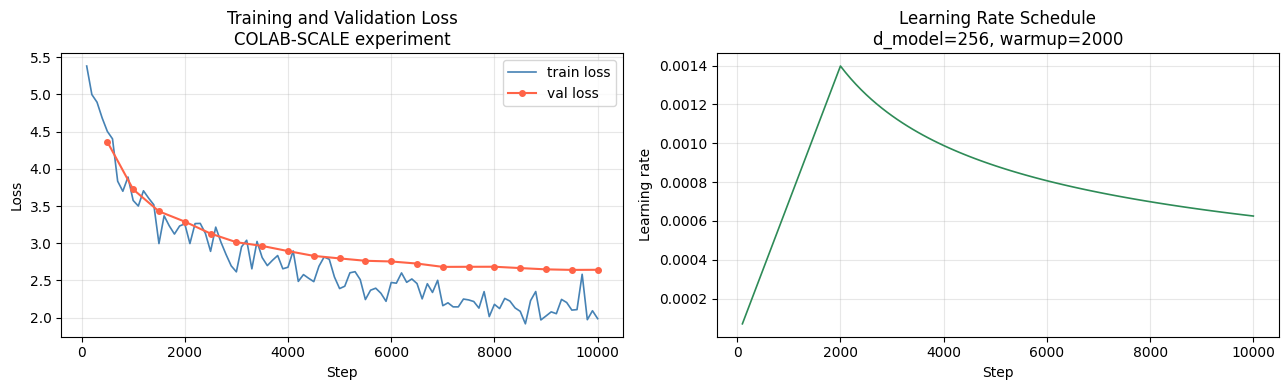

Training curves saved to: /content/drive/MyDrive/Transformer_Mine/figures/small_scale_training.png


In [28]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Training loss
ax1 = axes[0]
ax1.plot(history['step'], history['train_loss'],
         color='steelblue', linewidth=1.2, label='train loss')

if history['val_loss']:
    val_steps  = [v[0] for v in history['val_loss']]
    val_losses = [v[1] for v in history['val_loss']]
    ax1.plot(val_steps, val_losses,
             color='tomato', linewidth=1.5,
             marker='o', markersize=4, label='val loss')

ax1.set_xlabel('Step')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss\nCOLAB-SCALE experiment')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Learning rate
ax2 = axes[1]
ax2.plot(history['step'], history['lr'],
         color='seagreen', linewidth=1.2)
ax2.set_xlabel('Step')
ax2.set_ylabel('Learning rate')
ax2.set_title('Learning Rate Schedule\n'
              f'd_model={MODEL_CONFIG["d_model"]}, '
              f'warmup={TRAIN_CONFIG["warmup_steps"]}')
ax2.grid(True, alpha=0.3)

plt.tight_layout()

fig_path = os.path.join(FIGURES_DIR, 'small_scale_training.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"Training curves saved to: {fig_path}")

# 8: Sample Translations

Generates greedy translations for a few validation examples.

Not a BLEU evaluation — just a sanity check that the model is producing reasonable German output.


In [29]:

def greedy_decode(model, src_ids, tokenizer, max_len=50):
    """
    Greedy autoregressive decoding for one source sequence.

    Args:
        model : trained TiedTransformer
        src_ids : (1, src_len) integer tensor
        tokenizer : BPETokenizer
        max_len : maximum decode length

    Returns:
        decoded string
    """
    enc_mask = tf.cast(
        tf.equal(src_ids, tokenizer.pad_id), tf.float32
    )[:, tf.newaxis, tf.newaxis, :]

    enc_output, _ = model.encoder(src_ids, mask=enc_mask, training=False)
    dec_ids = tf.constant([[tokenizer.bos_id]], dtype=tf.int32)

    for _ in range(max_len):
        tgt_len  = tf.shape(dec_ids)[1]
        dec_mask = tf.maximum(
            1.0 - tf.linalg.band_part(
                tf.ones((1, 1, tgt_len, tgt_len)), -1, 0
            ),
            tf.cast(
                tf.equal(dec_ids, tokenizer.pad_id), tf.float32
            )[:, tf.newaxis, tf.newaxis, :],
        )

        dec_output, _ = model.decoder(
            dec_ids, enc_output,
            dec_mask=dec_mask,
            enc_mask=enc_mask,
            training=False,
        )

        embedding_weights = model.decoder.embedding.embeddings
        next_logits = tf.matmul(
            dec_output[:, -1:, :], embedding_weights, transpose_b=True
        )
        next_token = tf.argmax(next_logits, axis=-1, output_type=tf.int32)

        if next_token[0, 0].numpy() == tokenizer.eos_id:
            break

        dec_ids = tf.concat([dec_ids, next_token], axis=1)

    return tokenizer.decode(dec_ids[0, 1:].numpy().tolist())


In [30]:
n_samples = 10
for src, tgt in zip(src_val[:n_samples], tgt_val[:n_samples]):
    src_ids   = tokenizer.encode_with_special(src)
    src_tensor = tf.constant([src_ids], dtype=tf.int32)
    prediction = greedy_decode(model, src_tensor, tokenizer)

    print(f"src  : {src}")
    print(f"tgt  : {tgt}")
    print(f"pred : {prediction}")
    print()

src  : She left.
tgt  : Sie ist gegangen.
pred : Sie ging .

src  : Where are you all?
tgt  : Wo seid ihr alle?
pred : Wo bist du ?

src  : Can we believe that?
tgt  : Können wir das glauben?
pred : Können wir das glauben ?

src  : Tom stood rigid.
tgt  : Tom stand unbeweglich.
pred : Tom stand besserlich .

src  : He likes buying notebooks.
tgt  : Er kauft gerne Notizblöcke.
pred : Er isst gerne Notizenzenenenenenenenenenenenenenenenenenenenenenenenenenenenenenenenenenenenenenenenenenenen

src  : I'm being honest.
tgt  : Ich bin ehrlich.
pred : Ich bin ehrlich .

src  : Do you like this?
tgt  : Magst du das?
pred : Mögen Sie das ?

src  : Someone's talking.
tgt  : Jemand redet.
pred : Jemand redet .

src  : Tom stayed seated.
tgt  : Tom blieb sitzen.
pred : Tom blieb sitzen .

src  : Was Tom alone?
tgt  : War Tom allein?
pred : War Tom allein ?



#9: Log Results to CSV

In [31]:

final_train_loss = history['train_loss'][-1] if history['train_loss'] else None
final_val_loss   = history['val_loss'][-1][1] if history['val_loss'] else None

FIELDNAMES = [
    'experiment_id', 'model_config', 'dataset', 'dataset_size',
    'epochs', 'steps', 'batch_size', 'd_model', 'num_heads',
    'num_layers', 'd_ff', 'dropout', 'label_smoothing',
    'learning_rate', 'warmup_steps', 'parameters', 'gpu',
    'training_time', 'validation_loss', 'BLEU', 'checkpoint', 'notes',
]

gpu_name = gpu_info.get('name', 'unknown')

record = {
    'experiment_id'  : EXPERIMENT_ID,
    'model_config'   : f'COLAB-SCALE ({MODEL_CONFIG["num_layers"]}L, '
                       f'd{MODEL_CONFIG["d_model"]}, '
                       f'h{MODEL_CONFIG["num_heads"]}, '
                       f'ff{MODEL_CONFIG["d_ff"]})',
    'dataset'        : 'Stage B — Tatoeba EN-DE',
    'dataset_size'   : len(src_train),
    'epochs'         : 'N/A (step-based)',
    'steps'          : step,
    'batch_size'     : BATCH_SIZE,
    'd_model'        : MODEL_CONFIG['d_model'],
    'num_heads'      : MODEL_CONFIG['num_heads'],
    'num_layers'     : MODEL_CONFIG['num_layers'],
    'd_ff'           : MODEL_CONFIG['d_ff'],
    'dropout'        : MODEL_CONFIG['dropout'],
    'label_smoothing': TRAIN_CONFIG['label_smoothing'],
    'learning_rate'  : f'TransformerLRSchedule(d_model={MODEL_CONFIG["d_model"]}, '
                       f'warmup={TRAIN_CONFIG["warmup_steps"]})',
    'warmup_steps'   : TRAIN_CONFIG['warmup_steps'],
    'parameters'     : total_params,
    'gpu'            : gpu_name,
    'training_time'  : f'{total_time:.0f}s',
    'validation_loss': f'{final_val_loss:.4f}' if final_val_loss else '',
    'BLEU'           : 'N/A — see Phase 14',
    'checkpoint'     : final_ckpt,
    'notes'          : 'COLAB-SCALE experiment. Not paper reproduction.',
}

file_exists = os.path.exists(EXPERIMENTS_CSV)
with open(EXPERIMENTS_CSV, 'a', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=FIELDNAMES)
    if not file_exists:
        writer.writeheader()
    writer.writerow({k: record.get(k, '') for k in FIELDNAMES})

print(f"Results logged to: {EXPERIMENTS_CSV}")
print()
print("Summary:")
print(f"  Experiment       : {EXPERIMENT_ID}")
print(f"  Model            : COLAB-SCALE")
print(f"  Dataset          : Stage B Tatoeba")
print(f"  Steps            : {step}")
print(f"  Final train loss : {final_train_loss:.4f}")
print(f"  Final val loss   : {final_val_loss:.4f}")
print(f"  Training time    : {total_time:.0f}s")
print(f"  Parameters       : {total_params:,}")
print(f"  GPU              : {gpu_name}")

Results logged to: /content/drive/MyDrive/Transformer_Mine/experiments/results.csv

Summary:
  Experiment       : small_scale_01
  Model            : COLAB-SCALE
  Dataset          : Stage B Tatoeba
  Steps            : 10000
  Final train loss : 1.9874
  Final val loss   : 2.6436
  Training time    : 2097s
  Parameters       : 9,616,384
  GPU              : Tesla T4
